In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import sys

PROJECT_ROOT = Path("../..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import CONFIG
from src.labeling.utils import ms_to_suffix

In [180]:
SYMBOL = "SBUX"
START_DATE = "2025-12-01"
END_DATE = "2026-01-01"

FILE_NAME = (
    f"XNAS_ITCH_{SYMBOL}_mbo_{START_DATE.replace('-', '')}_{END_DATE.replace('-', '')}"
)

file_path = Path("../../data") / "datasets" / f"raw_dataset_{FILE_NAME}.parquet"

In [203]:
df = pd.read_parquet(file_path)

In [204]:
df.shape

(22000, 48)

In [205]:
df.columns

Index(['order_id', 'entry_time', 'duration_s', 'event', 'status_reason',
       'price', 'side', 'volume', 'order_type', 'best_bid_at_entry',
       'best_ask_at_entry', 'best_bid_at_post_trade', 'best_ask_at_post_trade',
       'post_trade_best_bid_1ms', 'post_trade_best_ask_1ms',
       'post_trade_best_bid_10ms', 'post_trade_best_ask_10ms',
       'post_trade_best_bid_50ms', 'post_trade_best_ask_50ms',
       'post_trade_best_bid_100ms', 'post_trade_best_ask_100ms',
       'post_trade_best_bid_200ms', 'post_trade_best_ask_200ms',
       'post_trade_best_bid_500ms', 'post_trade_best_ask_500ms',
       'post_trade_best_bid_1.0s', 'post_trade_best_ask_1.0s',
       'post_trade_best_bid_2.0s', 'post_trade_best_ask_2.0s',
       'post_trade_best_bid_5.0s', 'post_trade_best_ask_5.0s',
       'post_trade_best_bid_10.0s', 'post_trade_best_ask_10.0s',
       'post_trade_best_bid_30.0s', 'post_trade_best_ask_30.0s',
       'post_trade_best_bid_60s', 'post_trade_best_ask_60s',
       'entry_re

In [206]:
windows = CONFIG.labeling.tox_post_trade_move_windows_ms
target_cols = ["order_id", "entry_time", "duration_s", "event", "status_reason", "price", "side", "best_bid_at_entry", "best_ask_at_entry"]
post_trade_cols = []
for window in windows:
    post_trade_cols.append(f"post_trade_best_bid_{ms_to_suffix(window)}")
    post_trade_cols.append(f"post_trade_best_ask_{ms_to_suffix(window)}")
target_cols.extend(post_trade_cols)

In [207]:
df = df[target_cols]

In [208]:
df.status_reason.value_counts()

status_reason
FILLED          21865
CENSORED_END      135
Name: count, dtype: int64

In [209]:
df[df[post_trade_cols].isna().any(axis=1) & (df.status_reason == "FILLED")]

,order_id,entry_time,duration_s,event,status_reason,price,side,best_bid_at_entry,best_ask_at_entry,post_trade_best_bid_1ms,...,post_trade_best_bid_2.0s,post_trade_best_ask_2.0s,post_trade_best_bid_5.0s,post_trade_best_ask_5.0s,post_trade_best_bid_10.0s,post_trade_best_ask_10.0s,post_trade_best_bid_30.0s,post_trade_best_ask_30.0s,post_trade_best_bid_60s,post_trade_best_ask_60s
997,997,1764622745348716800,0.279766,1,FILLED,84830000000,A,84820000000,84830000000,8.482000e+10,...,8.485000e+10,8.486000e+10,8.487000e+10,8.488000e+10,8.487000e+10,8.488000e+10,8.486000e+10,8.487000e+10,NaN,NaN
998,996,1764622745348716800,14.734436,1,FILLED,84820000000,B,84820000000,84830000000,8.487000e+10,...,8.487000e+10,8.488000e+10,8.486000e+10,8.487000e+10,8.486000e+10,8.487000e+10,8.488000e+10,8.489000e+10,NaN,NaN
999,999,1764622781529217280,0.985016,1,FILLED,84870000000,A,84860000000,84870000000,8.486000e+10,...,8.488000e+10,8.489000e+10,8.488000e+10,8.489000e+10,8.489000e+10,8.490000e+10,NaN,NaN,NaN,NaN
1998,1998,1764709135572382464,27.988756,1,FILLED,85210000000,B,85210000000,85220000000,8.520000e+10,...,8.520000e+10,8.521000e+10,8.519000e+10,8.520000e+10,8.520000e+10,8.521000e+10,8.516000e+10,8.517000e+10,NaN,NaN
1999,1997,1764709110382329600,78.009216,1,FILLED,85270000000,A,85260000000,85270000000,8.515000e+10,...,8.514000e+10,8.515000e+10,8.516000e+10,8.517000e+10,8.519000e+10,8.520000e+10,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21995,2996,1767214754618752256,5.375040,1,FILLED,84210000000,B,84210000000,84220000000,8.421000e+10,...,8.421000e+10,8.422000e+10,8.421000e+10,8.422000e+10,8.419000e+10,8.420000e+10,8.420000e+10,8.421000e+10,NaN,NaN
21996,2997,1767214754618752256,18.980252,1,FILLED,84220000000,A,84210000000,84220000000,8.421000e+10,...,8.422000e+10,8.423000e+10,8.421000e+10,8.422000e+10,8.421000e+10,8.422000e+10,NaN,NaN,NaN,NaN
21997,2999,1767214782693315328,0.017785,1,FILLED,84210000000,A,84200000000,84210000000,8.421000e+10,...,8.420000e+10,8.421000e+10,8.420000e+10,8.421000e+10,8.421000e+10,8.422000e+10,NaN,NaN,NaN,NaN
21998,2998,1767214782693315328,3.402015,1,FILLED,84200000000,B,84200000000,84210000000,8.420000e+10,...,8.420000e+10,8.421000e+10,8.421000e+10,8.422000e+10,8.422000e+10,8.423000e+10,NaN,NaN,NaN,NaN


In [210]:
df = df.dropna(subset=post_trade_cols)

In [165]:
def compute_markouts_and_stats(
    df: pd.DataFrame,
    use_fill_price_for_markout: bool = False,
    in_bps: bool = True,
    winsorize: bool = False,
    winsor_lower: float = 0.01,
    winsor_upper: float = 0.99,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Compute signed post-trade markouts and aggregate statistics.

    Parameters
    ----------
    df
        Input dataframe.

    use_fill_price_for_markout
        False: entry mid base (recommended)
        True: fill price base

    in_bps
        True: output in bps

    winsorize
        Whether to winsorize markouts before aggregation.

    winsor_lower / winsor_upper
        Quantiles for clipping (e.g. 0.01 / 0.99)

    Returns
    -------
    df_out, stats
    """
    out = df.copy()

    # Core reference columns
    out["mid_at_entry"] = (out["best_bid_at_entry"] + out["best_ask_at_entry"]) / 2.0
    out["side_sign"] = np.where(out["side"].eq("B"), 1.0, -1.0)
    out["markout_base"] = (
        out["price"].astype(float)
        if use_fill_price_for_markout
        else out["mid_at_entry"].astype(float)
    )

    markout_cols = []
    horizon_labels = []

    for window in windows:
        suffix = ms_to_suffix(window)
        bid_col = f"post_trade_best_bid_{suffix}"
        ask_col = f"post_trade_best_ask_{suffix}"

        mid_col = f"post_trade_mid_{suffix}"
        markout_col = f"markout_{suffix}"

        out[mid_col] = (out[bid_col] + out[ask_col]) / 2.0

        signed_markout = out["side_sign"] * (out[mid_col] - out["markout_base"])

        if in_bps:
            out[markout_col] = 10000.0 * signed_markout / out["markout_base"]
        else:
            out[markout_col] = signed_markout

        markout_cols.append(markout_col)
        horizon_labels.append(suffix)

    if winsorize:
        for col in markout_cols:
            x = out[col]
            lower = x.quantile(winsor_lower)
            upper = x.quantile(winsor_upper)
            out[col] = x.clip(lower, upper)

    stats = _aggregate_markout_stats(
        df=out,
        markout_cols=markout_cols,
        horizon_labels=horizon_labels,
    )

    return out, stats


def _aggregate_markout_stats(
    df: pd.DataFrame,
    markout_cols: list[str],
    horizon_labels: list[str],
) -> pd.DataFrame:
    rows = []

    for window, label, col in zip(windows, horizon_labels, markout_cols):
        x = df[col].replace([np.inf, -np.inf], np.nan).dropna()
        n = len(x)

        if n == 0:
            rows.append({
                "window_ms": window,
                "horizon": label,
                "n": 0,
                "mean": np.nan,
                "std": np.nan,
                "se": np.nan,
                "tstat": np.nan,
                "median": np.nan,
                "p05": np.nan,
                "p25": np.nan,
                "p75": np.nan,
                "p95": np.nan,
                "toxic_rate": np.nan,
            })
            continue

        mean = x.mean()
        std = x.std(ddof=1) if n > 1 else np.nan
        se = std / np.sqrt(n) if n > 1 else np.nan
        tstat = mean / se if pd.notna(se) and se > 0 else np.nan

        rows.append({
            "window_ms": window,
            "horizon": label,
            "n": n,
            "mean": mean,
            "std": std,
            "se": se,
            "tstat": tstat,
            "median": x.median(),
            "p05": x.quantile(0.05),
            "p25": x.quantile(0.25),
            "p75": x.quantile(0.75),
            "p95": x.quantile(0.95),
            "toxic_rate": (x < 0).mean(),
        })

    return pd.DataFrame(rows).sort_values("window_ms").reset_index(drop=True)

In [211]:
df_mk, stats = compute_markouts_and_stats(
    df=df,
    use_fill_price_for_markout=False,
    in_bps=True,
    winsorize=True
)

In [212]:
stats

,window_ms,horizon,n,mean,std,se,tstat,median,p05,p25,p75,p95,toxic_rate
0,1,1ms,21623,-0.061039,3.422135,0.023272,-2.622817,-1.157809,-2.938912,-1.744998,0.000000,8.214516,0.671923
1,10,10ms,21623,-0.127593,3.560272,0.024212,-5.269894,-1.151808,-3.516587,-1.754283,0.000000,8.240772,0.656847
2,50,50ms,21623,-0.136715,3.630416,0.024689,-5.537550,-1.143641,-3.604167,-1.757160,-0.000000,8.362403,0.650095
3,100,100ms,21623,-0.140207,3.657900,0.024876,-5.636309,-1.128032,-3.895295,-1.757675,0.000000,8.400135,0.646580
4,200,200ms,21623,-0.144642,3.703700,0.025187,-5.742722,-1.126063,-4.059830,-1.758602,0.000000,8.442291,0.643158
5,500,500ms,21623,-0.146701,3.738040,0.025421,-5.770957,-1.116508,-4.104368,-1.760357,0.000000,8.595502,0.637516
6,1000,1.0s,21623,-0.169711,3.778991,0.025699,-6.603764,-1.123722,-4.181551,-1.767617,0.558441,8.515818,0.632891
7,2000,2.0s,21623,-0.181509,3.889380,0.026450,-6.862391,-1.123911,-4.676722,-1.779307,0.580282,8.688250,0.625538
8,5000,5.0s,21623,-0.217111,4.145199,0.028190,-7.701842,-1.114703,-5.260820,-2.305476,0.588253,8.847419,0.607733
9,10000,10.0s,21623,-0.236031,4.487219,0.030515,-7.734810,-0.604339,-6.088594,-2.352111,1.161170,9.467400,0.588679


In [150]:
def plot_markout_stats(
    stats: pd.DataFrame,
    mean_col: str = "mean",
    se_col: str = "se",
    median_col: str = "median",
    toxic_rate_col: str = "toxic_rate",
    horizon_ms_col: str = "window_ms",
    horizon_label_col: str = "horizon",
    show_median: bool = True,
    show_toxic_rate: bool = True,
    ci_z: float = 1.96,
):
    plot_df = stats.copy().sort_values(horizon_ms_col).reset_index(drop=True)

    x = plot_df[horizon_ms_col].to_numpy(dtype=float)
    mean = plot_df[mean_col].to_numpy(dtype=float)
    se = plot_df[se_col].to_numpy(dtype=float)

    ci_low = mean - ci_z * se
    ci_high = mean + ci_z * se

    plt.figure(figsize=(10, 5))
    plt.plot(x, mean, marker="o", label="Mean markout")
    plt.fill_between(x, ci_low, ci_high, alpha=0.2, label="95% confidence band")

    if show_median and median_col in plot_df.columns:
        median = plot_df[median_col].to_numpy(dtype=float)
        plt.plot(x, median, marker="s", linestyle="--", label="Median markout")

    plt.axhline(0.0, linewidth=1)
    plt.xscale("log")
    plt.xticks(x, plot_df[horizon_label_col].tolist(), rotation=45)
    plt.xlabel("Horizon")
    plt.ylabel("Signed markout (bps)")
    plt.title("Markout curve by horizon")
    plt.legend()
    plt.tight_layout()
    plt.grid()
    plt.show()

    if show_toxic_rate and toxic_rate_col in plot_df.columns:
        toxic_rate = plot_df[toxic_rate_col].to_numpy(dtype=float)

        plt.figure(figsize=(10, 4))
        plt.plot(x, toxic_rate, marker="o", label="Toxic rate")
        plt.axhline(0.5, linewidth=1, linestyle="--", label="50%")
        plt.xscale("log")
        plt.xticks(x, plot_df[horizon_label_col].tolist(), rotation=45)
        plt.xlabel("Horizon")
        plt.ylabel("Fraction negative")
        plt.title("Toxic rate by horizon")
        plt.legend()
        plt.tight_layout()
        plt.show()

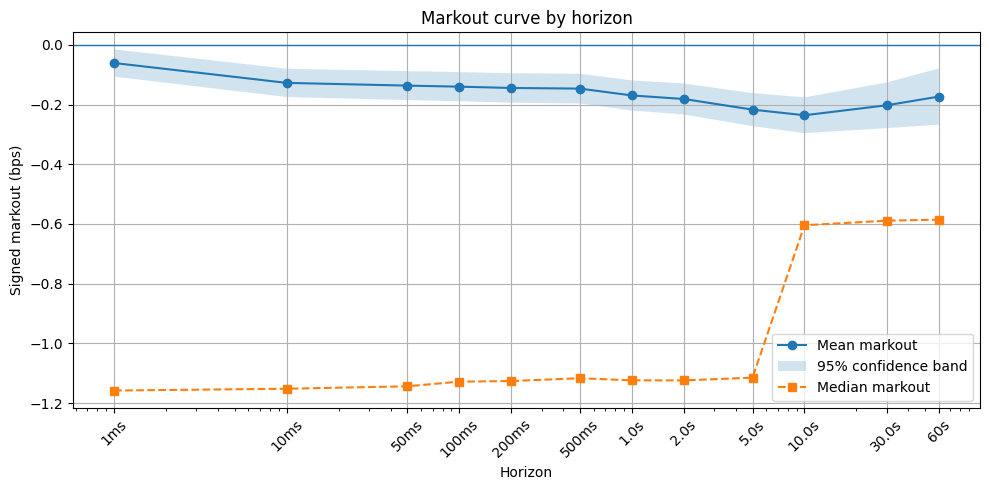

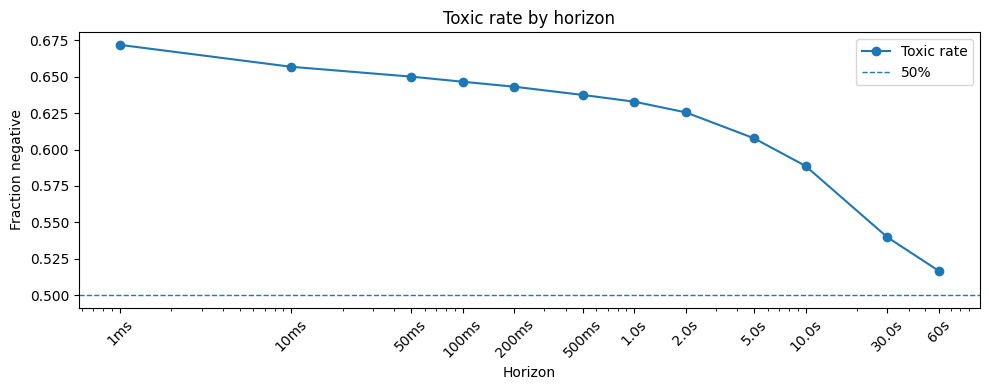

In [213]:
plot_markout_stats(stats)

In [152]:
def find_stabilization_window(
    stats: pd.DataFrame,
    fraction: float = 0.90,
    mean_col: str = "mean",
    window_col: str = "window_ms",
    horizon_col: str = "horizon",
) -> dict:
    """
    Find the earliest horizon where the absolute mean markout has reached
    `fraction` of the absolute long-run markout.

    Parameters
    ----------
    stats : pd.DataFrame
        Expected to contain at least:
            - window_ms
            - horizon
            - mean

    fraction : float
        Fraction of the long-run absolute markout to require, e.g. 0.90 or 0.95.

    mean_col : str
        Column containing the average markout.

    window_col : str
        Numeric horizon column in milliseconds.

    horizon_col : str
        Human-readable horizon label, e.g. "1ms", "10ms", "1.0s".

    Returns
    -------
    result : dict
        Contains:
            - chosen_window_ms
            - chosen_horizon
            - chosen_mean
            - threshold_abs_mean
            - long_run_window_ms
            - long_run_horizon
            - long_run_mean
            - fraction
            - found
    """
    if stats.empty:
        return {
            "found": False,
            "reason": "stats is empty",
        }

    df = stats[[window_col, horizon_col, mean_col]].copy()
    df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=[window_col, mean_col])
    df = df.sort_values(window_col).reset_index(drop=True)

    if df.empty:
        return {
            "found": False,
            "reason": "no valid rows after dropping NaNs/Infs",
        }

    long_run_row = df.iloc[-1]
    long_run_mean = float(long_run_row[mean_col])
    long_run_abs = abs(long_run_mean)

    if long_run_abs == 0:
        return {
            "found": False,
            "reason": "long-run mean markout is zero, stabilization threshold is undefined",
            "long_run_window_ms": int(long_run_row[window_col]),
            "long_run_horizon": long_run_row[horizon_col],
            "long_run_mean": long_run_mean,
        }

    threshold = fraction * long_run_abs
    long_run_sign = np.sign(long_run_mean)

    candidate_mask = df[mean_col].abs() >= threshold
    candidate_mask &= np.sign(df[mean_col]) == long_run_sign

    candidates = df.loc[candidate_mask]

    if candidates.empty:
        return {
            "found": False,
            "reason": "no horizon reaches the requested fraction of long-run absolute markout",
            "threshold_abs_mean": threshold,
            "long_run_window_ms": int(long_run_row[window_col]),
            "long_run_horizon": long_run_row[horizon_col],
            "long_run_mean": long_run_mean,
            "fraction": fraction,
        }

    chosen = candidates.iloc[0]

    return {
        "found": True,
        "chosen_window_ms": int(chosen[window_col]),
        "chosen_horizon": chosen[horizon_col],
        "chosen_mean": float(chosen[mean_col]),
        "threshold_abs_mean": threshold,
        "long_run_window_ms": int(long_run_row[window_col]),
        "long_run_horizon": long_run_row[horizon_col],
        "long_run_mean": long_run_mean,
        "fraction": fraction,
    }

In [214]:
find_stabilization_window(stats, fraction=0.9)

{'found': True,
 'chosen_window_ms': 1000,
 'chosen_horizon': '1.0s',
 'chosen_mean': -0.16971078688300648,
 'threshold_abs_mean': 0.1561590233443762,
 'long_run_window_ms': 60000,
 'long_run_horizon': '60s',
 'long_run_mean': -0.17351002593819578,
 'fraction': 0.9}